# IMPORTING LIBRARIES

In [14]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score, classification_report
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

import xgboost as xgb

warnings.filterwarnings("ignore")
plt.style.use("default")
sns.set_style("whitegrid")

# LOADING DATASET

In [15]:
DATA_PATH = r"C:\Users\sapav\Downloads\acndata_sessions (8).json"

with open(DATA_PATH, "r", encoding="utf-8", errors="ignore") as fh:
    raw = fh.read()

raw_fixed = raw.rstrip().rstrip(",").rstrip() + "\n  ]\n}"
data = json.loads(raw_fixed)
sessions = data["_items"]

print(f"      Raw sessions : {len(sessions):,}")

      Raw sessions : 13,299


# Engineering features

In [16]:

DATE_FMT = "%a, %d %b %Y %H:%M:%S GMT"

def parse_dt(s):
    try:
        return datetime.strptime(s, DATE_FMT) if s else None
    except Exception:
        return None

rows = []
for s in sessions:
    conn = parse_dt(s.get("connectionTime"))
    disc = parse_dt(s.get("disconnectTime"))
    done = parse_dt(s.get("doneChargingTime"))
    kwh = s.get("kWhDelivered")

    if conn is None or disc is None or kwh is None or kwh <= 0:
        continue
    if disc <= conn:
        continue

    session_hrs = (disc - conn).total_seconds() / 3600
    if session_hrs <= 0:
        continue

    if done:
        charge_hrs = max((done - conn).total_seconds() / 3600, 0.01)
        idle_hrs = max((disc - done).total_seconds() / 3600, 0.0)
    else:
        charge_hrs = session_hrs
        idle_hrs = 0.0

    avg_power_kw = kwh / charge_hrs

    rows.append({
        "hour_of_day": conn.hour,
        "day_of_week": conn.strftime("%A"),
        "month": conn.month,
        "is_weekend": int(conn.weekday() >= 5),
        "is_business_hours": int(8 <= conn.hour <= 18),
        "kWhDelivered": kwh,
        "charging_duration": round(charge_hrs, 4),
        "plug_duration": round(session_hrs, 4),
        "idle_time": round(idle_hrs, 4),
        "charge_ratio": round(charge_hrs / session_hrs, 4),
        "cluster_id": int(s.get("clusterID", 0)),
        "charging_power_kw": round(avg_power_kw, 4),
        "connection_hour": conn.hour
    })

df = pd.DataFrame(rows)
p99 = df["charging_power_kw"].quantile(0.99)
df = df[df["charging_power_kw"] <= p99].reset_index(drop=True)

print(f"      Valid sessions  : {len(df):,}  (after 99th-pct clip at {p99:.2f} kW)")
print(f"      Feature columns : {df.shape[1] - 1}  (excl. target)")
print("\n      Target (charging_power_kw) summary:")
print(df["charging_power_kw"].describe().to_string(float_format=lambda x: f"{x:.3f}"))

      Valid sessions  : 13,166  (after 99th-pct clip at 6.84 kW)
      Feature columns : 12  (excl. target)

      Target (charging_power_kw) summary:
count   13166.000
mean        3.500
std         1.799
min         0.046
25%         2.045
50%         3.085
75%         5.313
max         6.844


# DATA INSPECTION

In [17]:

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nDescriptive statistics (numeric columns):")
display(df.describe())

print("\nDescriptive statistics (all columns):")
display(df.describe(include='all'))

print("\nMissing values per column:")
display(df.isnull().sum())

print("\nMissing values percentage per column:")
display((df.isnull().sum() / len(df) * 100).round(2))

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique values per column:")
display(df.nunique())


First 5 rows:


,hour_of_day,day_of_week,month,is_weekend,is_business_hours,kWhDelivered,charging_duration,plug_duration,idle_time,charge_ratio,cluster_id,charging_power_kw,connection_hour
0,11,Wednesday,4,0,1,7.932,2.2183,2.2017,0.0000,1.0076,39,3.5757,11
1,13,Wednesday,4,0,1,10.013,2.9847,11.1850,8.2003,0.2669,39,3.3548,13
2,13,Wednesday,4,0,1,5.257,1.0983,9.3153,8.2169,0.1179,39,4.7863,13
3,14,Wednesday,4,0,1,5.177,1.4711,9.3078,7.8367,0.1581,39,3.5191,14
4,14,Wednesday,4,0,1,10.119,2.9989,8.3772,5.3783,0.3580,39,3.3742,14



Last 5 rows:


,hour_of_day,day_of_week,month,is_weekend,is_business_hours,kWhDelivered,charging_duration,plug_duration,idle_time,charge_ratio,cluster_id,charging_power_kw,connection_hour
13161,16,Monday,11,0,1,13.049000,4.0489,8.9386,4.8897,0.4530,39,3.2229,16
13162,16,Monday,11,0,1,12.459000,4.3881,8.4153,4.0272,0.5214,39,2.8393,16
13163,16,Monday,11,0,1,10.073442,6.0475,9.6789,3.6314,0.6248,39,1.6657,16
13164,16,Monday,11,0,1,0.893000,5.7067,8.9289,3.2222,0.6391,39,0.1565,16
13165,16,Monday,11,0,1,4.502000,1.4997,3.8456,2.3458,0.3900,39,3.0019,16



Shape of dataset:
(13166, 13)

Column names:
['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_business_hours', 'kWhDelivered', 'charging_duration', 'plug_duration', 'idle_time', 'charge_ratio', 'cluster_id', 'charging_power_kw', 'connection_hour']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13166 entries, 0 to 13165
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   hour_of_day        13166 non-null  int64  
 1   day_of_week        13166 non-null  object 
 2   month              13166 non-null  int64  
 3   is_weekend         13166 non-null  int64  
 4   is_business_hours  13166 non-null  int64  
 5   kWhDelivered       13166 non-null  float64
 6   charging_duration  13166 non-null  float64
 7   plug_duration      13166 non-null  float64
 8   idle_time          13166 non-null  float64
 9   charge_ratio       13166 non-null  float64
 10  cluster_id         

...

hour_of_day          0
day_of_week          0
month                0
is_weekend           0
is_business_hours    0
kWhDelivered         0
charging_duration    0
plug_duration        0
idle_time            0
charge_ratio         0
cluster_id           0
charging_power_kw    0
connection_hour      0
dtype: int64


Missing values percentage per column:


hour_of_day          0.0
day_of_week          0.0
month                0.0
is_weekend           0.0
is_business_hours    0.0
kWhDelivered         0.0
charging_duration    0.0
plug_duration        0.0
idle_time            0.0
charge_ratio         0.0
cluster_id           0.0
charging_power_kw    0.0
connection_hour      0.0
dtype: float64


Duplicate rows:
0

Unique values per column:


hour_of_day             24
day_of_week              7
month                    8
is_weekend               2
is_business_hours        2
kWhDelivered          8774
charging_duration     9024
plug_duration        10404
idle_time             6653
charge_ratio          5625
cluster_id               1
charging_power_kw    11477
connection_hour         24
dtype: int64

# EDA

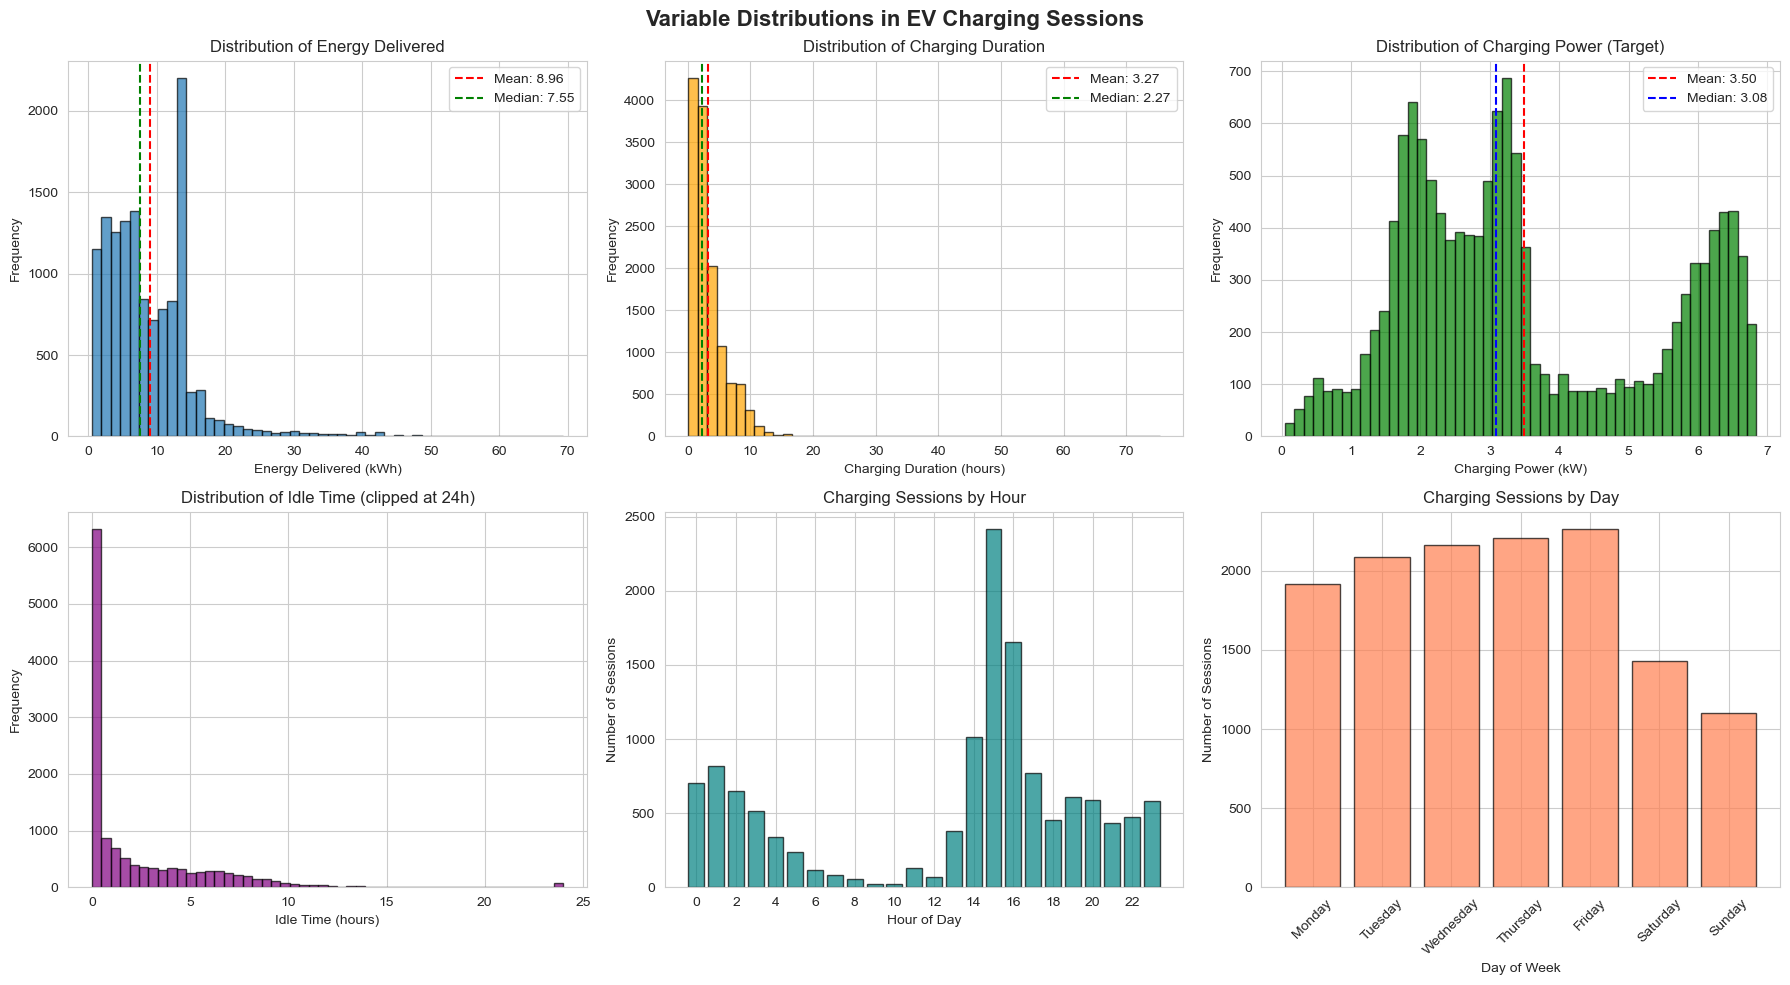

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Variable Distributions in EV Charging Sessions', fontsize=16, fontweight='bold')

axes[0,0].hist(df['kWhDelivered'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_xlabel('Energy Delivered (kWh)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Energy Delivered')
axes[0,0].axvline(df['kWhDelivered'].mean(), color='red', linestyle='--', label=f"Mean: {df['kWhDelivered'].mean():.2f}")
axes[0,0].axvline(df['kWhDelivered'].median(), color='green', linestyle='--', label=f"Median: {df['kWhDelivered'].median():.2f}")
axes[0,0].legend()

axes[0,1].hist(df['charging_duration'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0,1].set_xlabel('Charging Duration (hours)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of Charging Duration')
axes[0,1].axvline(df['charging_duration'].mean(), color='red', linestyle='--', label=f"Mean: {df['charging_duration'].mean():.2f}")
axes[0,1].axvline(df['charging_duration'].median(), color='green', linestyle='--', label=f"Median: {df['charging_duration'].median():.2f}")
axes[0,1].legend()

axes[0,2].hist(df['charging_power_kw'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0,2].set_xlabel('Charging Power (kW)')
axes[0,2].set_ylabel('Frequency')
axes[0,2].set_title('Distribution of Charging Power (Target)')
axes[0,2].axvline(df['charging_power_kw'].mean(), color='red', linestyle='--', label=f"Mean: {df['charging_power_kw'].mean():.2f}")
axes[0,2].axvline(df['charging_power_kw'].median(), color='blue', linestyle='--', label=f"Median: {df['charging_power_kw'].median():.2f}")
axes[0,2].legend()

axes[1,0].hist(df['idle_time'].clip(0, 24), bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1,0].set_xlabel('Idle Time (hours)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Idle Time (clipped at 24h)')

hour_counts = df['connection_hour'].value_counts().sort_index()
axes[1,1].bar(hour_counts.index, hour_counts.values, edgecolor='black', alpha=0.7, color='teal')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Number of Sessions')
axes[1,1].set_title('Charging Sessions by Hour')
axes[1,1].set_xticks(range(0,24,2))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)
axes[1,2].bar(day_counts.index, day_counts.values, edgecolor='black', alpha=0.7, color='coral')
axes[1,2].set_xlabel('Day of Week')
axes[1,2].set_ylabel('Number of Sessions')
axes[1,2].set_title('Charging Sessions by Day')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

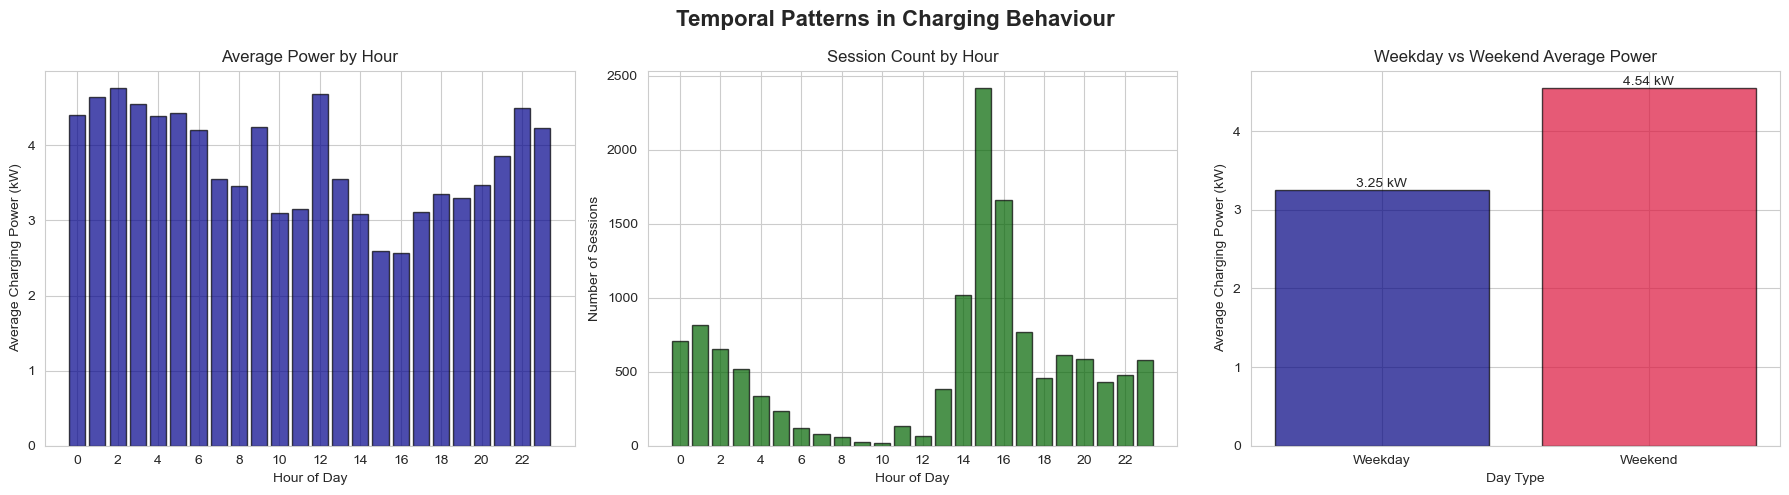

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Temporal Patterns in Charging Behaviour', fontsize=16, fontweight='bold')

hourly_power = df.groupby('connection_hour')['charging_power_kw'].mean()
hourly_count = df.groupby('connection_hour').size()

axes[0].bar(hourly_power.index, hourly_power.values, edgecolor='black', alpha=0.7, color='darkblue')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Charging Power (kW)')
axes[0].set_title('Average Power by Hour')
axes[0].set_xticks(range(0,24,2))

axes[1].bar(hourly_count.index, hourly_count.values, edgecolor='black', alpha=0.7, color='darkgreen')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Number of Sessions')
axes[1].set_title('Session Count by Hour')
axes[1].set_xticks(range(0,24,2))

weekend_power = df[df['is_weekend']==1]['charging_power_kw'].mean()
weekday_power = df[df['is_weekend']==0]['charging_power_kw'].mean()

bars = axes[2].bar(['Weekday', 'Weekend'], [weekday_power, weekend_power],
                   edgecolor='black', alpha=0.7, color=['navy', 'crimson'])
axes[2].set_xlabel('Day Type')
axes[2].set_ylabel('Average Charging Power (kW)')
axes[2].set_title('Weekday vs Weekend Average Power')

for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f} kW',
                 ha='center', va='bottom')

plt.tight_layout()

# Save the figure
plt.savefig('temporal_patterns_charging_behaviour.png', dpi=300, bbox_inches='tight')
plt.show()

# CORRELATION ANALYSIS

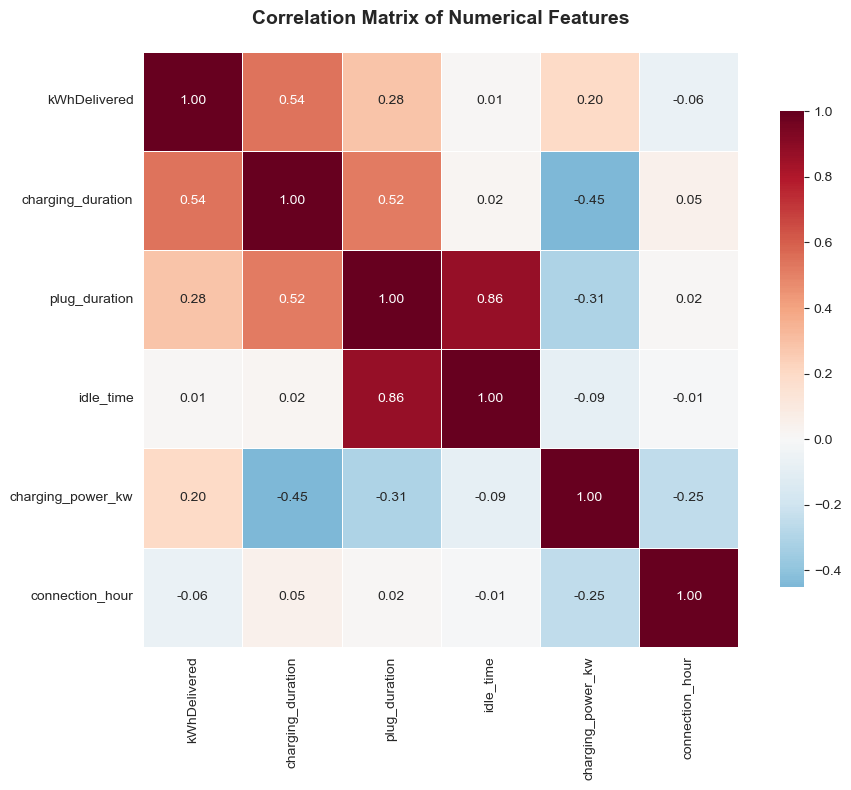


Strongest correlations with target variable (charging_power_kw):
  kWhDelivered: 0.199
  idle_time: -0.093
  connection_hour: -0.249
  plug_duration: -0.306
  charging_duration: -0.451


In [21]:
numeric_cols = ['kWhDelivered', 'charging_duration', 'plug_duration',
                'idle_time', 'charging_power_kw', 'connection_hour']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
# Save the figure
plt.savefig('Correlation Matrix of Numerical Features.png', dpi=300, bbox_inches='tight')

plt.show()

print("\nStrongest correlations with target variable (charging_power_kw):")
for var, corr in corr_matrix['charging_power_kw'].sort_values(ascending=False).items():
    if var != 'charging_power_kw':
        print(f"  {var}: {corr:.3f}")





# OUTLIER ANALYSIS

kWhDelivered: 300 outliers (2.3%) | Range: [-9.47, 26.81]
charging_duration: 743 outliers (5.6%) | Range: [-3.20, 8.76]
charging_power_kw: 0 outliers (0.0%) | Range: [-2.86, 10.22]


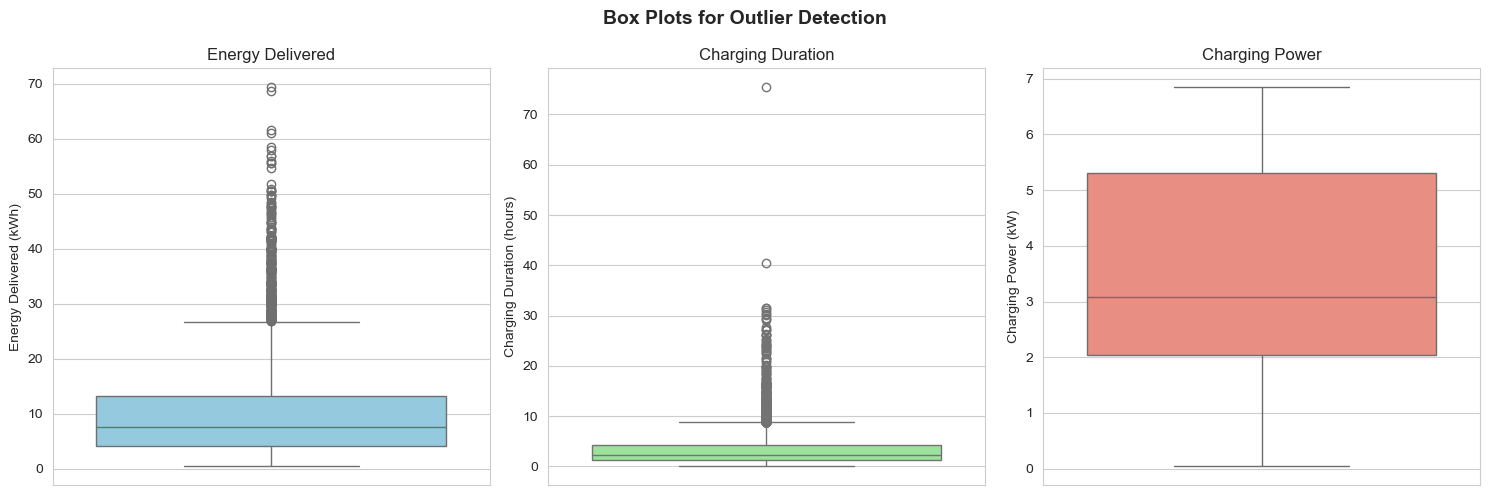

In [22]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for col in ['kWhDelivered', 'charging_duration', 'charging_power_kw']:
    n_outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"{col}: {n_outliers} outliers ({n_outliers/len(df)*100:.1f}%) | Range: [{lb:.2f}, {ub:.2f}]")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Box Plots for Outlier Detection', fontsize=14, fontweight='bold')

sns.boxplot(y=df['kWhDelivered'], ax=axes[0], color='skyblue')
axes[0].set_ylabel('Energy Delivered (kWh)')
axes[0].set_title('Energy Delivered')

sns.boxplot(y=df['charging_duration'], ax=axes[1], color='lightgreen')
axes[1].set_ylabel('Charging Duration (hours)')
axes[1].set_title('Charging Duration')

sns.boxplot(y=df['charging_power_kw'], ax=axes[2], color='salmon')
axes[2].set_ylabel('Charging Power (kW)')
axes[2].set_title('Charging Power')

plt.tight_layout()
plt.show()

# Splitting data (temporal — no leakage

In [23]:
FEATURE_COLS = [
    "hour_of_day", "is_weekend", "is_business_hours",
    "kWhDelivered", "charging_duration", "plug_duration",
    "idle_time", "charge_ratio", "cluster_id", "connection_hour"
]
TARGET = "charging_power_kw"

n = len(df)
n_train = int(n * 0.60)
n_cv = int(n * 0.20)

df_train = df.iloc[:n_train].copy()
df_cv = df.iloc[n_train:n_train + n_cv].copy()
df_test = df.iloc[n_train + n_cv:].copy()

X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET].values
X_cv = df_cv[FEATURE_COLS]
y_cv = df_cv[TARGET].values
X_test = df_test[FEATURE_COLS]
y_test = df_test[TARGET].values

print(f"      Train : {len(df_train):>5,} sessions  (60 %)")
print(f"      CV    : {len(df_cv):>5,} sessions  (20 %)")
print(f"      Test  : {len(df_test):>5,} sessions  (20 %)")

      Train : 7,899 sessions  (60 %)
      CV    : 2,633 sessions  (20 %)
      Test  : 2,634 sessions  (20 %)


In [24]:
reg_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]),
    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", xgb.XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            verbosity=0
        )),
    ]),
}

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 12, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 5],
}

xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

print("\n[5/11] Hyperparameter tuning and model training …")
print("-" * 65)

results = {}
kf = KFold(n_splits=5, shuffle=False)

for name, pipe in reg_models.items():
    print(f"\n  ▶  {name}")
    if name == "Random Forest":
        search = GridSearchCV(pipe, rf_param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
        search.fit(X_train, y_train)
        best_pipe = search.best_estimator_
        print(f"      Best params: {search.best_params_}")
    elif name == "XGBoost":
        search = GridSearchCV(pipe, xgb_param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
        search.fit(X_train, y_train)
        best_pipe = search.best_estimator_
        print(f"      Best params: {search.best_params_}")
    else:
        best_pipe = pipe.fit(X_train, y_train)
        print("      No tuning applied.")

    cv_r2 = cross_val_score(best_pipe, X_cv, y_cv, cv=kf, scoring="r2", n_jobs=-1)
    cv_rmse = cross_val_score(best_pipe, X_cv, y_cv, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)

    y_pred_train = best_pipe.predict(X_train)
    y_pred_test = best_pipe.predict(X_test)

    results[name] = {
        "pipe": best_pipe,
        "y_pred_test": y_pred_test,
        "train_r2": r2_score(y_train, y_pred_train),
        "test_r2": r2_score(y_test, y_pred_test),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "test_mae": mean_absolute_error(y_test, y_pred_test),
        "cv_r2_mean": cv_r2.mean(),
        "cv_r2_std": cv_r2.std(),
        "cv_rmse_mean": -cv_rmse.mean(),
        "cv_rmse_std": cv_rmse.std(),
    }

    r = results[name]
    print(f"      Train R² : {r['train_r2']:.4f}")
    print(f"      CV R²    : {r['cv_r2_mean']:.4f} ± {r['cv_r2_std']:.4f}")
    print(f"      Test R²  : {r['test_r2']:.4f}")
    print(f"      Test RMSE: {r['test_rmse']:.4f} kW")
    print(f"      Test MAE : {r['test_mae']:.4f} kW")


[5/11] Hyperparameter tuning and model training …
-----------------------------------------------------------------

  ▶  Linear Regression
      No tuning applied.
      Train R² : 0.6122
      CV R²    : 0.5726 ± 0.0212
      Test R²  : 0.4667
      Test RMSE: 1.3758 kW
      Test MAE : 0.9721 kW

  ▶  Random Forest
      Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
      Train R² : 0.9992
      CV R²    : 0.9832 ± 0.0056
      Test R²  : 0.9861
      Test RMSE: 0.2225 kW
      Test MAE : 0.1018 kW

  ▶  XGBoost
      Best params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 0.8}
      Train R² : 0.9993
      CV R²    : 0.9867 ± 0.0043
      Test R²  : 0.9916
      Test RMSE: 0.1730 kW
      Test MAE : 0.0978 kW


# REGRESSION RESULTS SUMMARY

In [25]:
hdr = f"{'Model':<22}{'Train R²':>9}{'CV R²':>10}{'Test R²':>9}{'Test RMSE':>11}{'Test MAE':>10}"
print(hdr)
print("-" * 65)

for name, r in results.items():
    print(f"{name:<22}{r['train_r2']:>9.4f}{r['cv_r2_mean']:>10.4f}{r['test_r2']:>9.4f}{r['test_rmse']:>11.4f}{r['test_mae']:>10.4f}")

best_name = max(results, key=lambda n: results[n]["test_r2"])
print(f"\n  ✓  Best model (Test R²): {best_name}  R²={results[best_name]['test_r2']:.4f}")

Model                  Train R²     CV R²  Test R²  Test RMSE  Test MAE
-----------------------------------------------------------------
Linear Regression        0.6122    0.5726   0.4667     1.3758    0.9721
Random Forest            0.9992    0.9832   0.9861     0.2225    0.1018
XGBoost                  0.9993    0.9867   0.9916     0.1730    0.0978

  ✓  Best model (Test R²): XGBoost  R²=0.9916


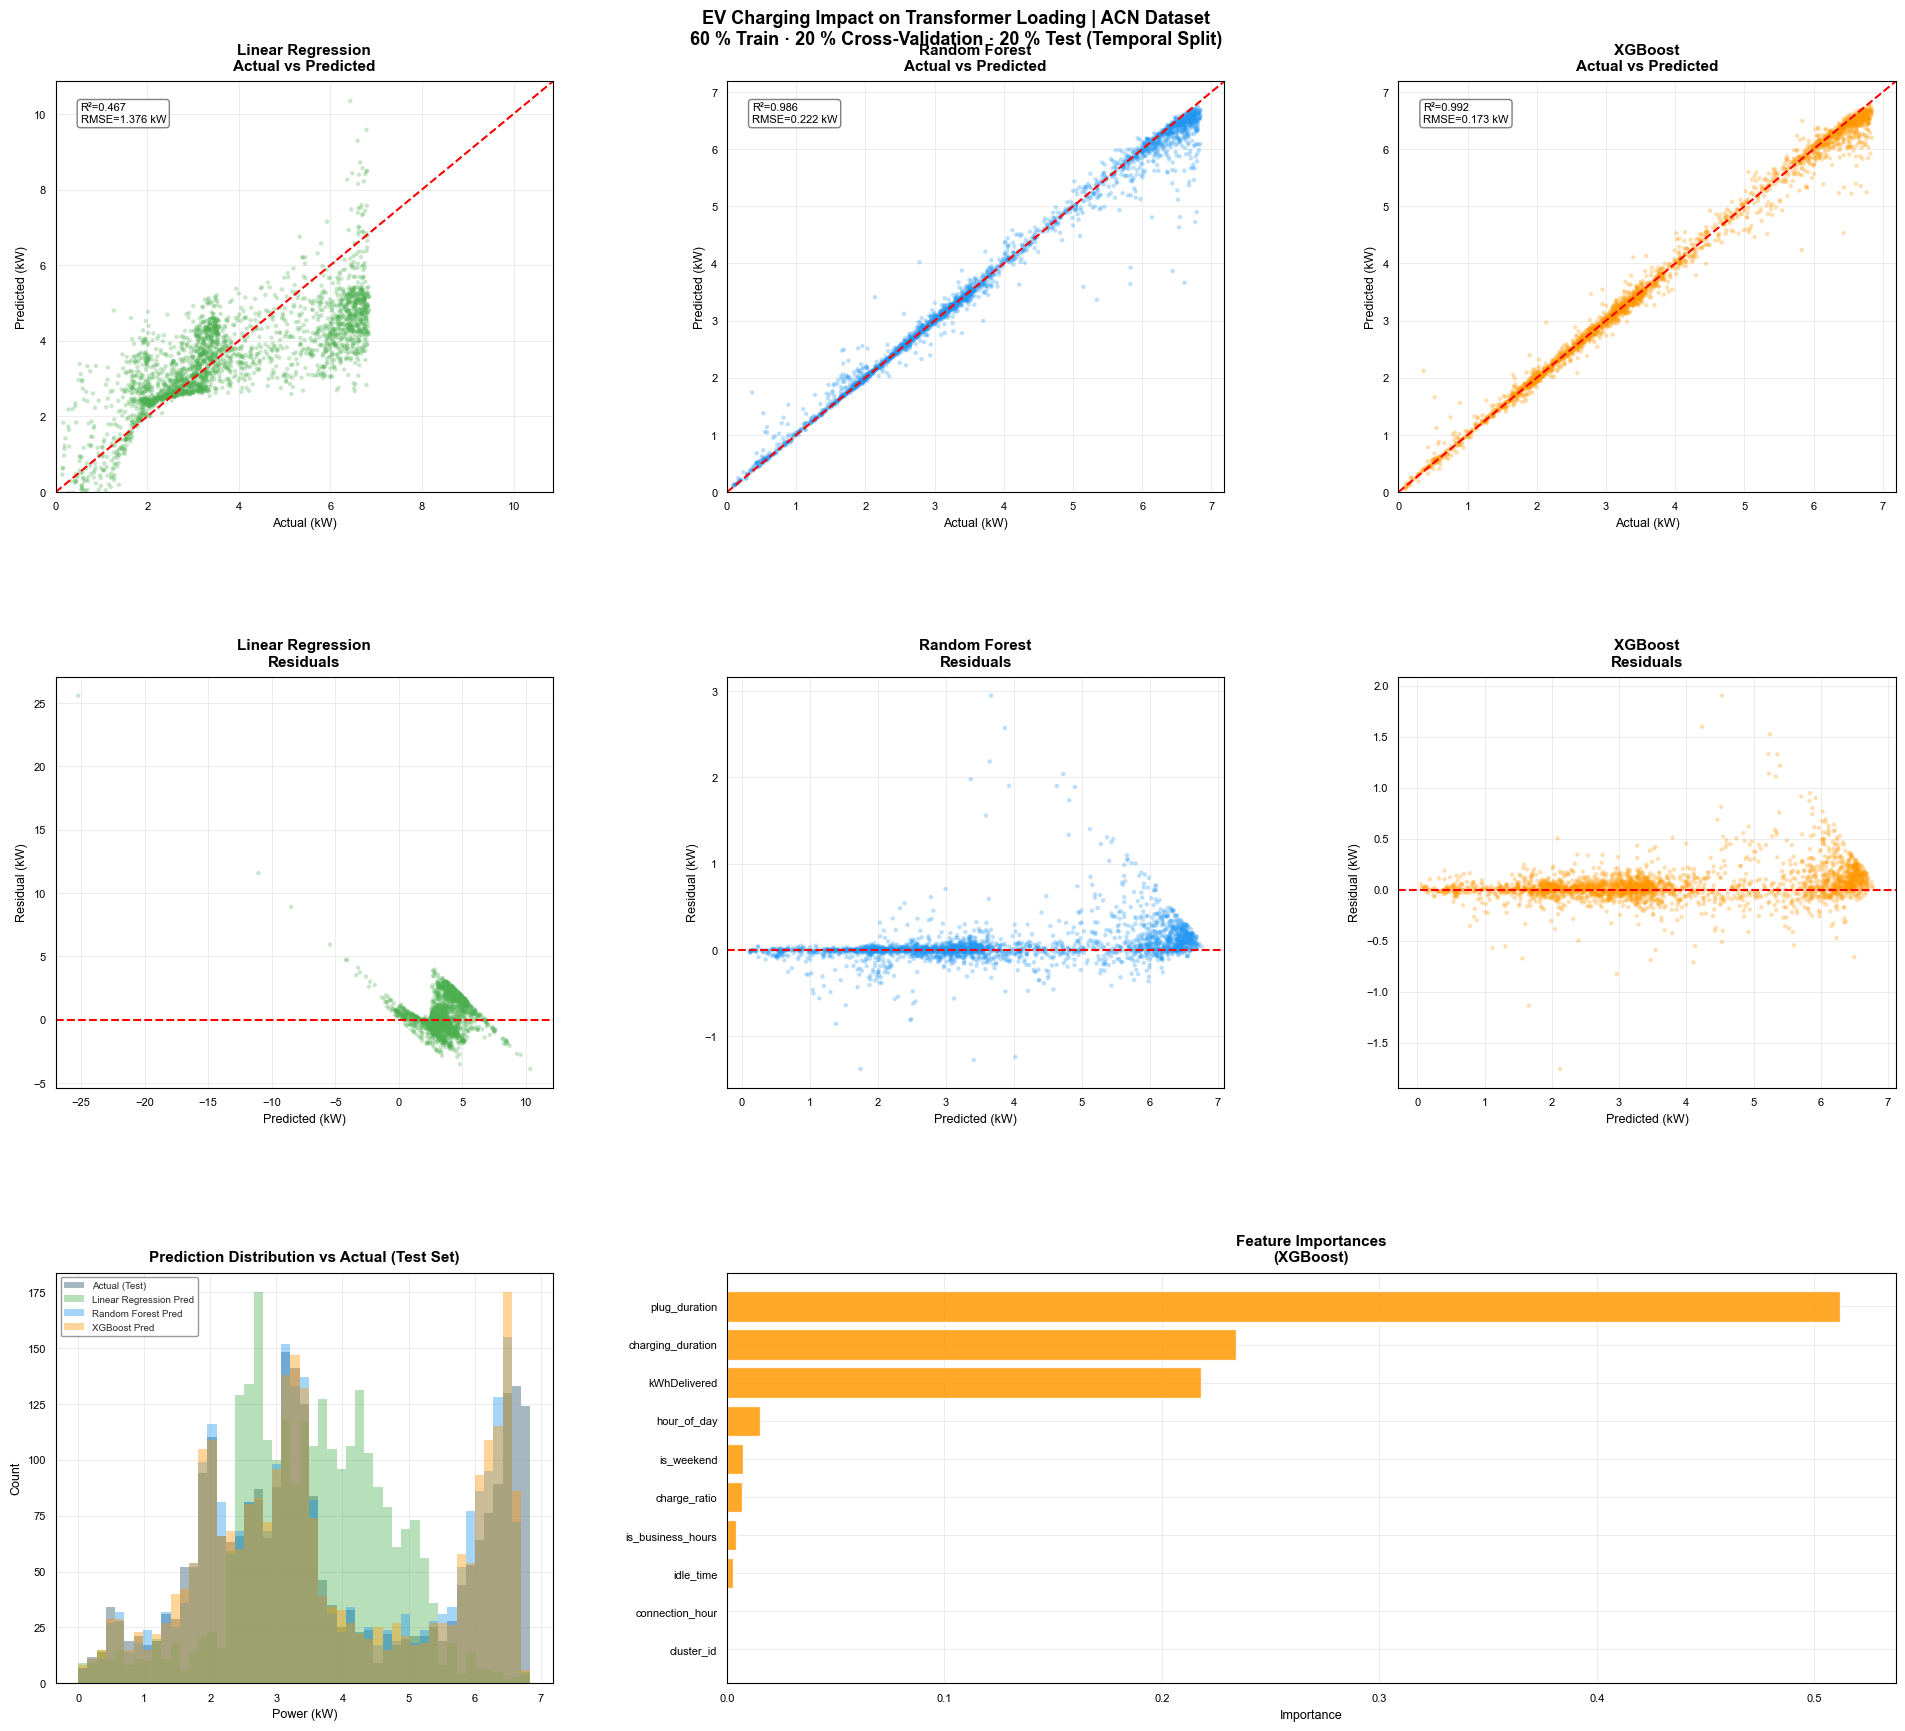

In [26]:
COLORS = {
    "Linear Regression": "#4CAF50",
    "Random Forest": "#2196F3",
    "XGBoost": "#FF9800",
}

fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35,
                       left=0.05, right=0.97, top=0.94, bottom=0.05)

def style_ax(ax, title, xlabel="", ylabel=""):
    ax.set_facecolor("white")
    ax.tick_params(colors="black", labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
    ax.set_title(title, fontsize=11, fontweight="bold", color="black", pad=8)
    if xlabel:
        ax.set_xlabel(xlabel, color="black", fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color="black", fontsize=9)
    ax.grid(True, color="#d9d9d9", linewidth=0.5, alpha=0.7)

for i, (name, r) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, i])
    lim = max(y_test.max(), r["y_pred_test"].max()) * 1.05
    ax.scatter(y_test, r["y_pred_test"], alpha=0.3, s=10, color=COLORS[name], edgecolors="none")
    ax.plot([0, lim], [0, lim], "--", color="red", lw=1.5)
    style_ax(ax, f"{name}\nActual vs Predicted", "Actual (kW)", "Predicted (kW)")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.text(0.05, 0.90, f"R²={r['test_r2']:.3f}\nRMSE={r['test_rmse']:.3f} kW",
            transform=ax.transAxes, color="black", fontsize=8,
            bbox=dict(facecolor="white", edgecolor="gray", boxstyle="round,pad=0.3"))

for i, (name, r) in enumerate(results.items()):
    ax = fig.add_subplot(gs[1, i])
    resid = y_test - r["y_pred_test"]
    ax.scatter(r["y_pred_test"], resid, alpha=0.3, s=10, color=COLORS[name], edgecolors="none")
    ax.axhline(0, color="red", lw=1.5, ls="--")
    style_ax(ax, f"{name}\nResiduals", "Predicted (kW)", "Residual (kW)")

ax_dist = fig.add_subplot(gs[2, 0])
bins = np.linspace(0, y_test.max(), 50)
ax_dist.hist(y_test, bins=bins, alpha=0.55, color="#607D8B", label="Actual (Test)", edgecolor="none")
for name, r in results.items():
    ax_dist.hist(r["y_pred_test"], bins=bins, alpha=0.40, color=COLORS[name], label=f"{name} Pred", edgecolor="none")
style_ax(ax_dist, "Prediction Distribution vs Actual (Test Set)", "Power (kW)", "Count")
ax_dist.legend(fontsize=7, facecolor="white", edgecolor="gray")

ax_fi = fig.add_subplot(gs[2, 1:])
if best_name != "Linear Regression":
    fi = results[best_name]["pipe"].named_steps["model"].feature_importances_
    sidx = np.argsort(fi)
    ax_fi.barh(range(len(sidx)), fi[sidx], color=COLORS[best_name], alpha=0.85)
    ax_fi.set_yticks(range(len(sidx)))
    ax_fi.set_yticklabels([FEATURE_COLS[i] for i in sidx], color="black", fontsize=7)
    style_ax(ax_fi, f"Feature Importances\n({best_name})", xlabel="Importance")
else:
    ax_fi.axis("off")

fig.suptitle(
    "EV Charging Impact on Transformer Loading | ACN Dataset\n"
    "60 % Train · 20 % Cross-Validation · 20 % Test (Temporal Split)",
    fontsize=13, fontweight="bold", color="black", y=0.98
)

plt.show()
plt.close()

# FEATURE IMPORTANCE ANALYSIS

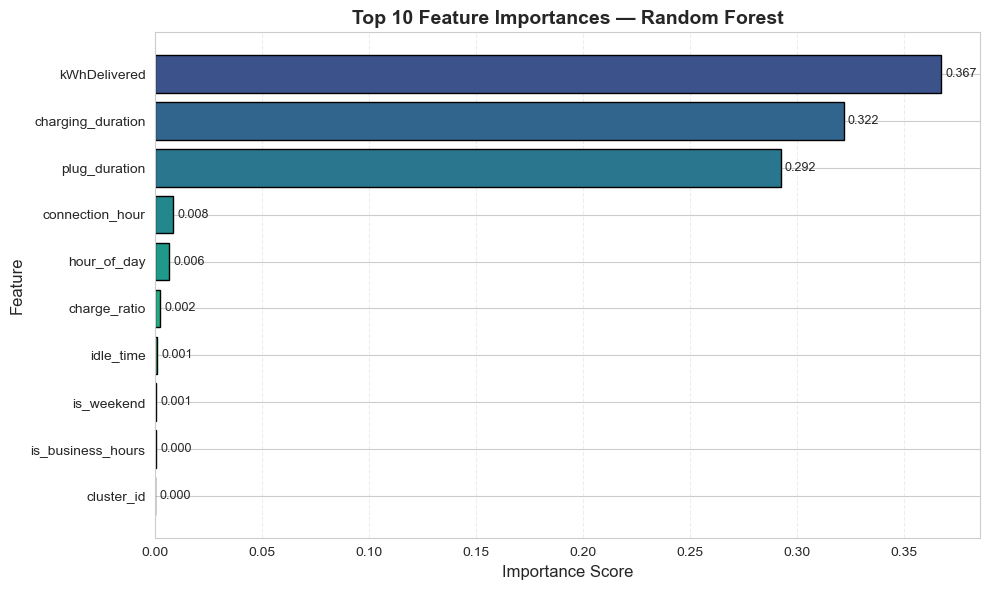

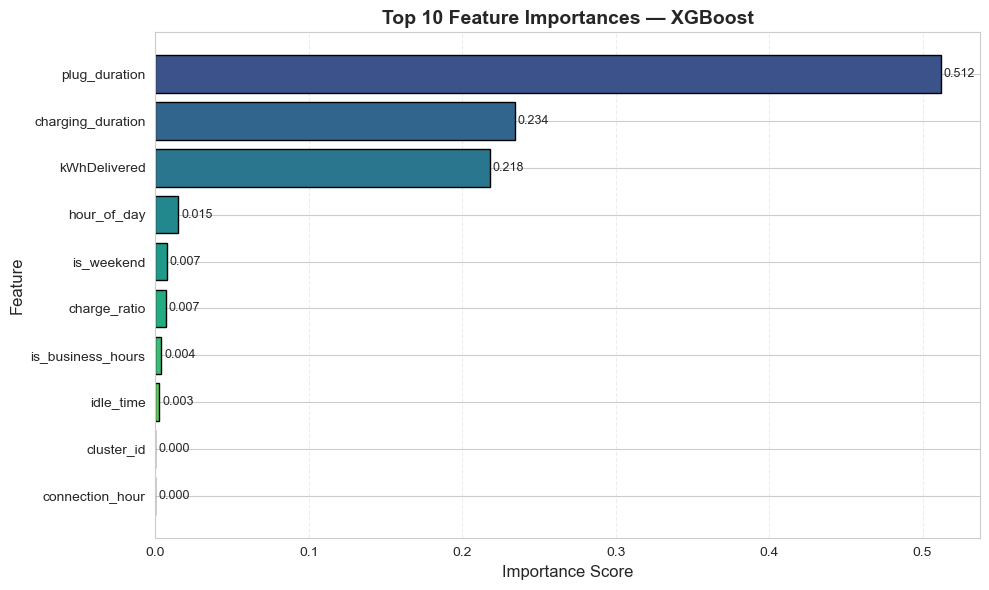

In [27]:
def plot_feature_importance(model_name, model, feature_names, top_n=10):
    if not hasattr(model, "feature_importances_") and not hasattr(model, "coef_"):
        print(f"{model_name} does not expose feature importance.")
        return

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    else:
        importances = np.abs(model.coef_)

    fi_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0.25, 0.9, len(fi_df)))

    bars = ax.barh(
        fi_df["feature"][::-1],
        fi_df["importance"][::-1],
        color=colors[::-1],
        edgecolor="black"
    )

    ax.set_title(f"Top {top_n} Feature Importances — {model_name}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Importance Score", fontsize=12)
    ax.set_ylabel("Feature", fontsize=12)
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.002, bar.get_y() + bar.get_height()/2,
                f"{width:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

if "Random Forest" in results:
    rf_model = results["Random Forest"]["pipe"].named_steps["model"]
    plot_feature_importance("Random Forest", rf_model, FEATURE_COLS, top_n=10)

if "XGBoost" in results:
    xgb_model = results["XGBoost"]["pipe"].named_steps["model"]
    plot_feature_importance("XGBoost", xgb_model, FEATURE_COLS, top_n=10)

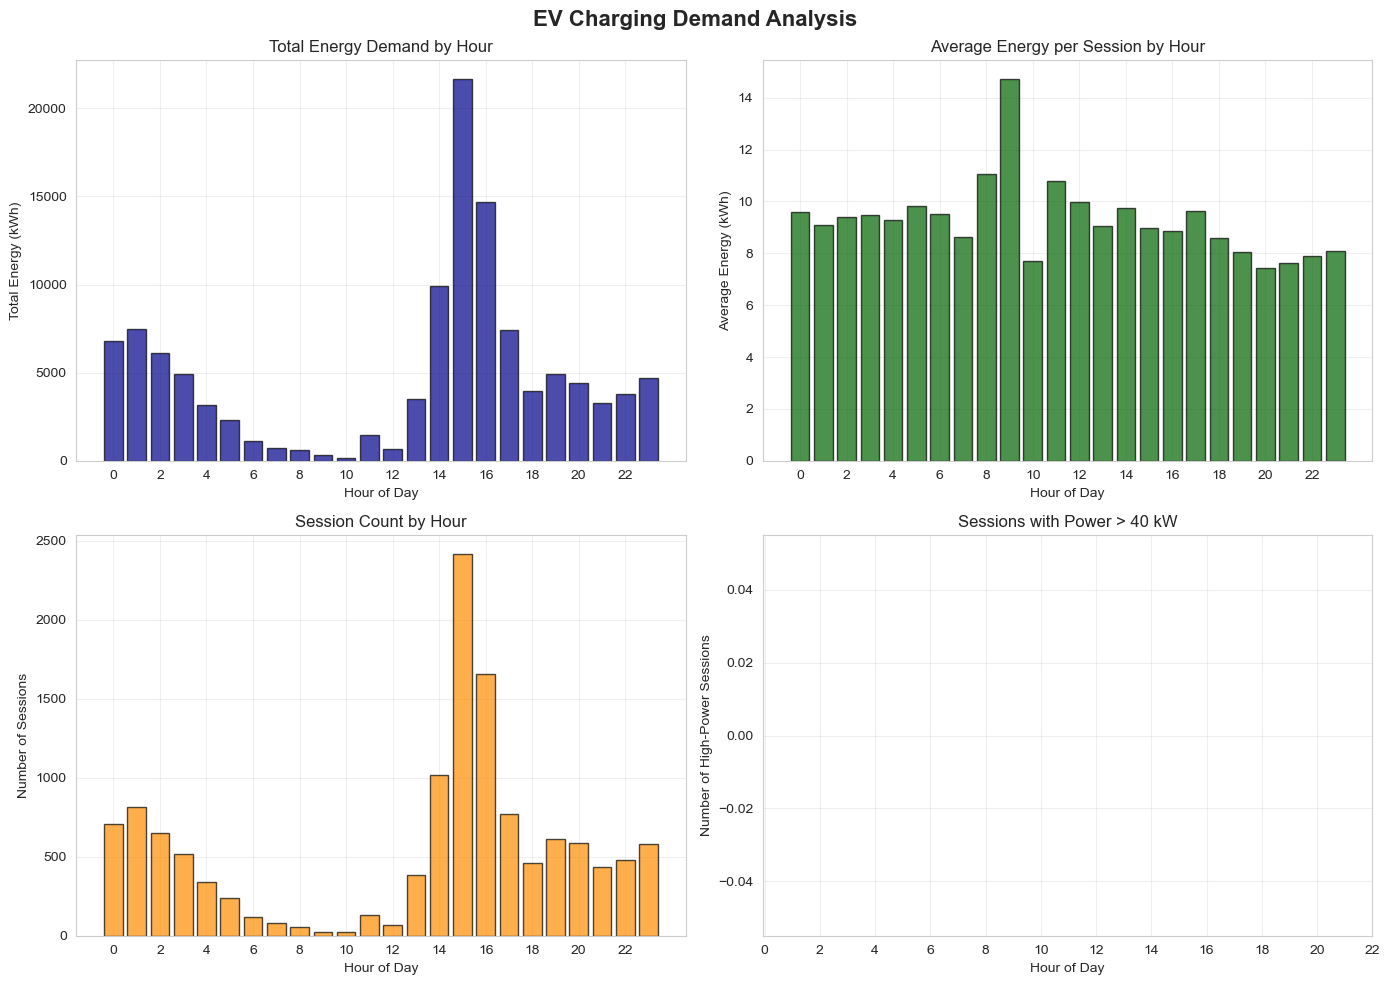


Peak Demand Analysis:
----------------------------------------
Peak hour (total energy): 15:00 (21635.0 kWh)
Peak hour (session count): 15:00 (2414 sessions)
High-power sessions (>40 kW): 0 (0.0% of total)


In [28]:
hourly_demand = df.groupby('connection_hour')['kWhDelivered'].agg(['sum', 'mean', 'count'])
hourly_demand.columns = ['total_energy_kWh', 'avg_energy_kWh', 'session_count']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EV Charging Demand Analysis', fontsize=16, fontweight='bold')

axes[0,0].bar(hourly_demand.index, hourly_demand['total_energy_kWh'],
              edgecolor='black', alpha=0.7, color='darkblue')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Total Energy (kWh)')
axes[0,0].set_title('Total Energy Demand by Hour')
axes[0,0].set_xticks(range(0,24,2))
axes[0,0].grid(True, alpha=0.3)

axes[0,1].bar(hourly_demand.index, hourly_demand['avg_energy_kWh'],
              edgecolor='black', alpha=0.7, color='darkgreen')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Average Energy (kWh)')
axes[0,1].set_title('Average Energy per Session by Hour')
axes[0,1].set_xticks(range(0,24,2))
axes[0,1].grid(True, alpha=0.3)

axes[1,0].bar(hourly_demand.index, hourly_demand['session_count'],
              edgecolor='black', alpha=0.7, color='darkorange')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Number of Sessions')
axes[1,0].set_title('Session Count by Hour')
axes[1,0].set_xticks(range(0,24,2))
axes[1,0].grid(True, alpha=0.3)

peak_threshold = 40
peak_sessions = df[df['charging_power_kw'] > peak_threshold]
peak_by_hour = peak_sessions.groupby('connection_hour').size()

axes[1,1].bar(peak_by_hour.index, peak_by_hour.values,
              edgecolor='black', alpha=0.7, color='crimson')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Number of High-Power Sessions')
axes[1,1].set_title(f'Sessions with Power > {peak_threshold} kW')
axes[1,1].set_xticks(range(0,24,2))
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPeak Demand Analysis:")
print("-"*40)
print(f"Peak hour (total energy): {hourly_demand['total_energy_kWh'].idxmax()}:00 ({hourly_demand['total_energy_kWh'].max():.1f} kWh)")
print(f"Peak hour (session count): {hourly_demand['session_count'].idxmax()}:00 ({hourly_demand['session_count'].max()} sessions)")
print(f"High-power sessions (>{peak_threshold} kW): {len(peak_sessions)} ({len(peak_sessions)/len(df)*100:.1f}% of total)")

# TRANSFORMER OVERLOAD DETECTION


Overload Risk Distribution:
  Normal sessions (≤50 kW): 13166 (100.0%)
  High-risk sessions (>50 kW): 0 (0.0%)


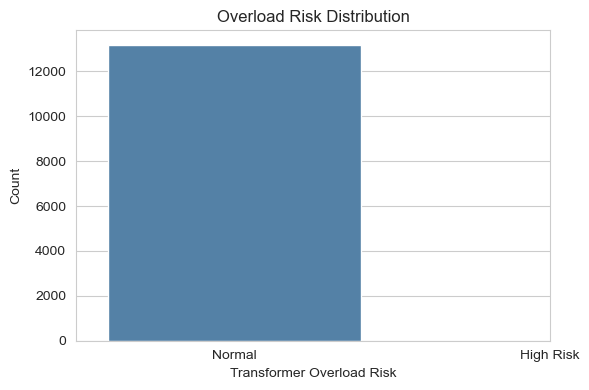

In [29]:
TRANSFORMER_CAPACITY = 50
df["overload_risk"] = (df["charging_power_kw"] > TRANSFORMER_CAPACITY).astype(int)

print("\nOverload Risk Distribution:")
print(f"  Normal sessions (≤{TRANSFORMER_CAPACITY} kW): {(df['overload_risk']==0).sum()} ({(df['overload_risk']==0).mean()*100:.1f}%)")
print(f"  High-risk sessions (>{TRANSFORMER_CAPACITY} kW): {(df['overload_risk']==1).sum()} ({(df['overload_risk']==1).mean()*100:.1f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(x="overload_risk", data=df, palette=["steelblue", "crimson"])
plt.xticks([0, 1], ["Normal", "High Risk"])
plt.xlabel("Transformer Overload Risk")
plt.ylabel("Count")
plt.title("Overload Risk Distribution")
plt.tight_layout()
plt.show()

# PRACTICAL APPLICATION SIMULATION

In [30]:
scenarios = pd.DataFrame({
    'scenario': [
        'Morning Commuter',
        'Afternoon Shopper',
        'Evening Resident',
        'Fast Charger',
        'Overnight Parking'
    ],
    'connection_hour': [8, 14, 19, 15, 22],
    'charging_duration': [2.5, 1.0, 4.0, 0.5, 8.0],
    'kWhDelivered': [15, 10, 25, 30, 20],
    'plug_duration': [2.7, 1.2, 4.2, 0.7, 8.4],
    'idle_time': [0.2, 0.2, 0.2, 0.2, 0.4],
    'is_weekend': [0, 1, 0, 0, 0],
    'is_business_hours': [1, 1, 0, 1, 0],
    'hour_of_day': [8, 14, 19, 15, 22],
    'cluster_id': [3, 3, 3, 3, 3]
})

scenarios["charge_ratio"] = scenarios["charging_duration"] / scenarios["plug_duration"]
scenario_features = scenarios[FEATURE_COLS]
scenario_predictions = results[best_name]["pipe"].predict(scenario_features)
scenario_overload_flag = (scenario_predictions > TRANSFORMER_CAPACITY).astype(int)

print("\nScenario Predictions:")
print("-"*80)
for idx, row in scenarios.iterrows():
    print(f"\n{row['scenario']}:")
    print(f"  Connection: {row['connection_hour']:02d}:00, Duration: {row['charging_duration']:.1f}h")
    print(f"  Requested: {row['kWhDelivered']:.0f} kWh, Available: {row['plug_duration']*60:.0f} min")
    print(f"  Predicted Load: {scenario_predictions[idx]:.2f} kW")
    print(f"  Overload Risk: {'YES' if scenario_overload_flag[idx] == 1 else 'NO'}")


Scenario Predictions:
--------------------------------------------------------------------------------

Morning Commuter:
  Connection: 08:00, Duration: 2.5h
  Requested: 15 kWh, Available: 162 min
  Predicted Load: 5.98 kW
  Overload Risk: NO

Afternoon Shopper:
  Connection: 14:00, Duration: 1.0h
  Requested: 10 kWh, Available: 72 min
  Predicted Load: 7.24 kW
  Overload Risk: NO

Evening Resident:
  Connection: 19:00, Duration: 4.0h
  Requested: 25 kWh, Available: 252 min
  Predicted Load: 6.26 kW
  Overload Risk: NO

Fast Charger:
  Connection: 15:00, Duration: 0.5h
  Requested: 30 kWh, Available: 42 min
  Predicted Load: 7.91 kW
  Overload Risk: NO

Overnight Parking:
  Connection: 22:00, Duration: 8.0h
  Requested: 20 kWh, Available: 504 min
  Predicted Load: 2.52 kW
  Overload Risk: NO


# FINAL REGRESSION SUMMARY

In [31]:
hdr = f"{'Model':<22}{'Train R²':>9}{'CV R²':>10}{'Test R²':>9}{'Test RMSE':>11}{'Test MAE':>10}"
print(hdr)
print("-" * 65)

for name, r in results.items():
    print(f"{name:<22}{r['train_r2']:>9.4f}{r['cv_r2_mean']:>10.4f}{r['test_r2']:>9.4f}{r['test_rmse']:>11.4f}{r['test_mae']:>10.4f}")

best_name = max(results, key=lambda n: results[n]["test_r2"])
print(f"\n  ✓  Best model (Test R²): {best_name}  R²={results[best_name]['test_r2']:.4f}")

Model                  Train R²     CV R²  Test R²  Test RMSE  Test MAE
-----------------------------------------------------------------
Linear Regression        0.6122    0.5726   0.4667     1.3758    0.9721
Random Forest            0.9992    0.9832   0.9861     0.2225    0.1018
XGBoost                  0.9993    0.9867   0.9916     0.1730    0.0978

  ✓  Best model (Test R²): XGBoost  R²=0.9916
